# Combinar/Merging DataFrames 🔗

In [1]:
import pandas as pd

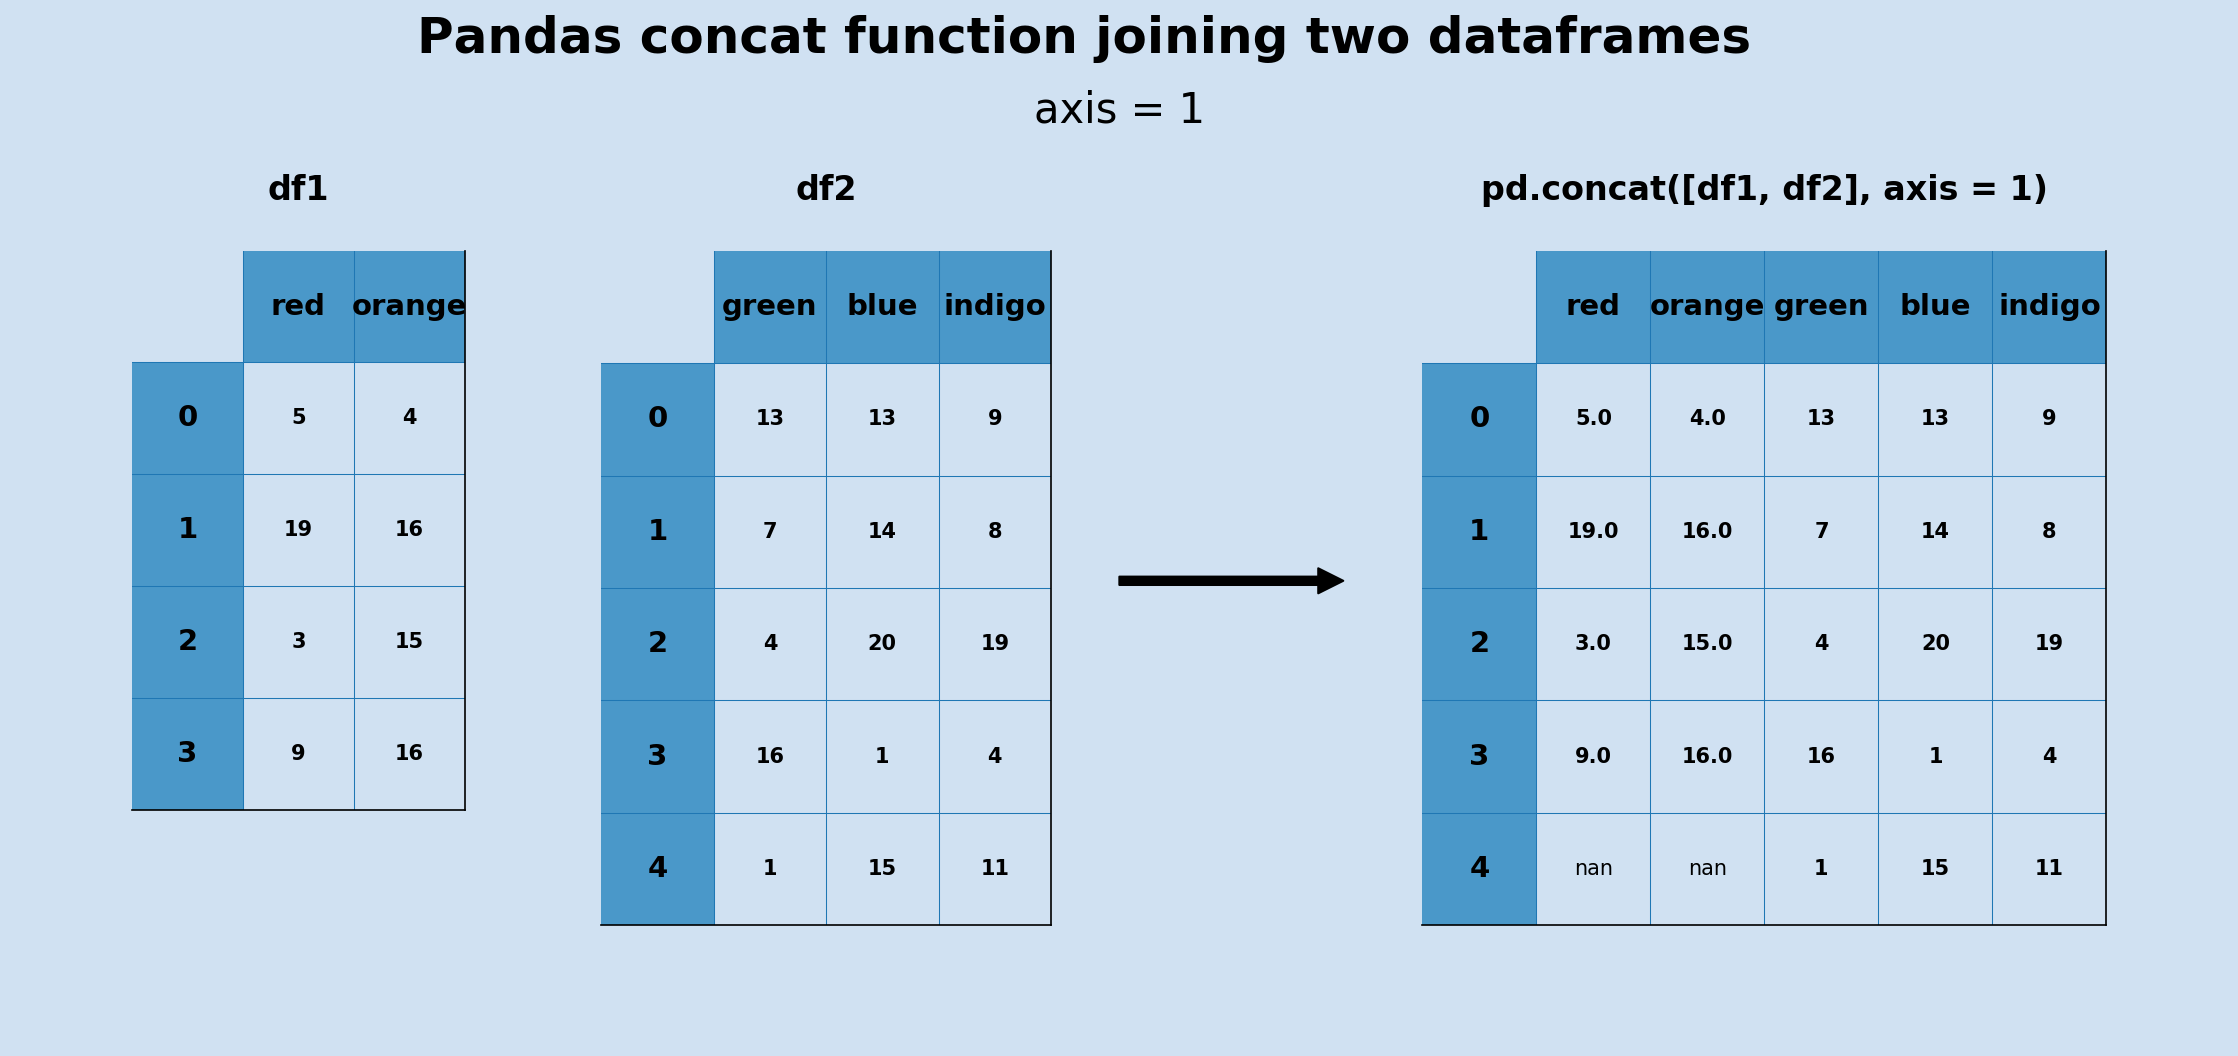

## Nuestro Conjunto de Datos 📂
- Los datos están distribuidos en múltiples archivos, todos con el prefijo `restaurant_`.
- El archivo `customers.csv` almacena los clientes del restaurante.
- El archivo `foods.csv` almacena los elementos del menú del restaurante.
- Los archivos `week_1_sales` y `week_2_sales` almacenan los pedidos realizados.

In [2]:
import os
#ruta del archivo actual
curr_path = os.getcwd()
print(curr_path)

datasets_path = os.path.join(curr_path, "..", "All_Datasets")
print(datasets_path)

c:\Users\MATEOCRACK\Desktop\familia\santi\factultade\proc_limpieza_visualizazcion\teoria
c:\Users\MATEOCRACK\Desktop\familia\santi\factultade\proc_limpieza_visualizazcion\teoria\..\All_Datasets


In [3]:
foods = pd.read_csv(datasets_path + "/restaurant_foods.csv", sep =";")
customers = pd.read_csv(datasets_path+ "/restaurant_customers.csv",sep =";")
week1 = pd.read_csv(datasets_path+ "/restaurant_week_1_sales.csv",sep =";")
week2 = pd.read_csv(datasets_path + "/restaurant_week_2_sales.csv",sep =";")

In [13]:
week2

,Customer ID,Food ID
0,688,1
1,813,7
2,495,1
3,189,5
4,267,3
...,...,...
245,783,1
246,556,1
247,547,9
248,252,9


In [14]:
customers

,ID,First Name,Last Name,Gender,Company,Occupation
0,1,Joseph,Perkins,Male,Dynazzy,Community Outreach Specialist
1,2,Jennifer,Alvarez,Female,DabZ,Senior Quality Engineer
2,3,Roger,Black,Male,Tagfeed,Account Executive
3,4,Steven,Evans,Male,Fatz,Registered Nurse
4,5,Judy,Morrison,Female,Demivee,Legal Assistant
...,...,...,...,...,...,...
995,996,Debra,Garcia,Female,Dazzlesphere,Structural Engineer
996,997,Douglas,Bishop,Male,Livepath,Developer I
997,998,Frank,Franklin,Male,Brainverse,Nurse Practicioner
998,999,Jessica,Burns,Female,Babbleblab,Financial Advisor


In [15]:
week1

,Customer ID,Food ID
0,537,9
1,97,4
2,658,1
3,202,2
4,155,9
...,...,...
245,413,9
246,926,6
247,134,3
248,396,6


In [16]:
week2

,Customer ID,Food ID
0,688,1
1,813,7
2,495,1
3,189,5
4,267,3
...,...,...
245,783,1
246,556,1
247,547,9
248,252,9


## La Función `pd.concat` I ➕
- La función `concat` concatena un **DataFrame** al final de otro.
- Por defecto, se conservan las etiquetas de índice originales. Usa `ignore_index=True` para generar un nuevo índice.
- El parámetro `keys` crea un **MultiIndex** utilizando las claves/etiquetas especificadas.

Le tenes que pasar como parametro una lista con los dataframes a unir

In [30]:
df = pd.concat([week1, week2], ignore_index=False) #esto es por default
display(df.loc[245]) #es un dataframe si los indices no son unicos

display(df)

#
df_multi_index = pd.concat([week1, week2], keys=["Week 1", "Week 2"]) #crear un indice multindex asociado a cada dataset
display(df_multi_index.loc["Week 1"].loc[4])



,Customer ID,Food ID
245,413,9
245,783,1


,Customer ID,Food ID
0,537,9
1,97,4
2,658,1
3,202,2
4,155,9
...,...,...
245,783,1
246,556,1
247,547,9
248,252,9


Customer ID    155
Food ID          9
Name: 4, dtype: int64

## La Función `pd.concat` II ↔️
- Pandas concatena los **DataFrames** a lo largo del eje de filas/índice por defecto.
- Se incluyen todas las columnas que existen en cualquiera de los **DataFrames**. Los valores no coincidentes se llenan con `NaN`.
- Usa el parámetro `axis="columns"` para concatenar a lo largo del eje de columnas.


In [31]:
df1 = pd.DataFrame([1, 2, 3], columns=["A"])
display(df1)
df2 = pd.DataFrame([4, 5, 6], columns=["B"])
display(df2)

,A
0,1
1,2
2,3


,B
0,4
1,5
2,6


In [34]:
display(pd.concat([df1, df2], axis=0)) #esto concatena por defecto a lo largo de las filas
#display(pd.concat([df1, df2], axis="index")) #esto concatena por defecto a lo largo de las filas

display(pd.concat([df1, df2], axis=1)) #esto concatena por defecto a lo largo de las filas
#display(pd.concat([df1, df2], axis="columns")) #esto concatena por defecto a lo largo de las filas

,A,B
0,1.0,NaN
1,2.0,NaN
2,3.0,NaN
0,NaN,4.0
1,NaN,5.0
2,NaN,6.0


,A,B
0,1,4
1,2,5
2,3,6


## Joins Izquierdos (Left Joins) ⬅️
- El método `merge` combina dos **DataFrames** basándose en valores compartidos en una columna o índice.
- Un **left join** combina un **DataFrame** con otro utilizando los valores del primero.
- Si un valor en el **DataFrame** izquierdo no se encuentra en el derecho, la fila correspondiente tendrá valores `NaN`.



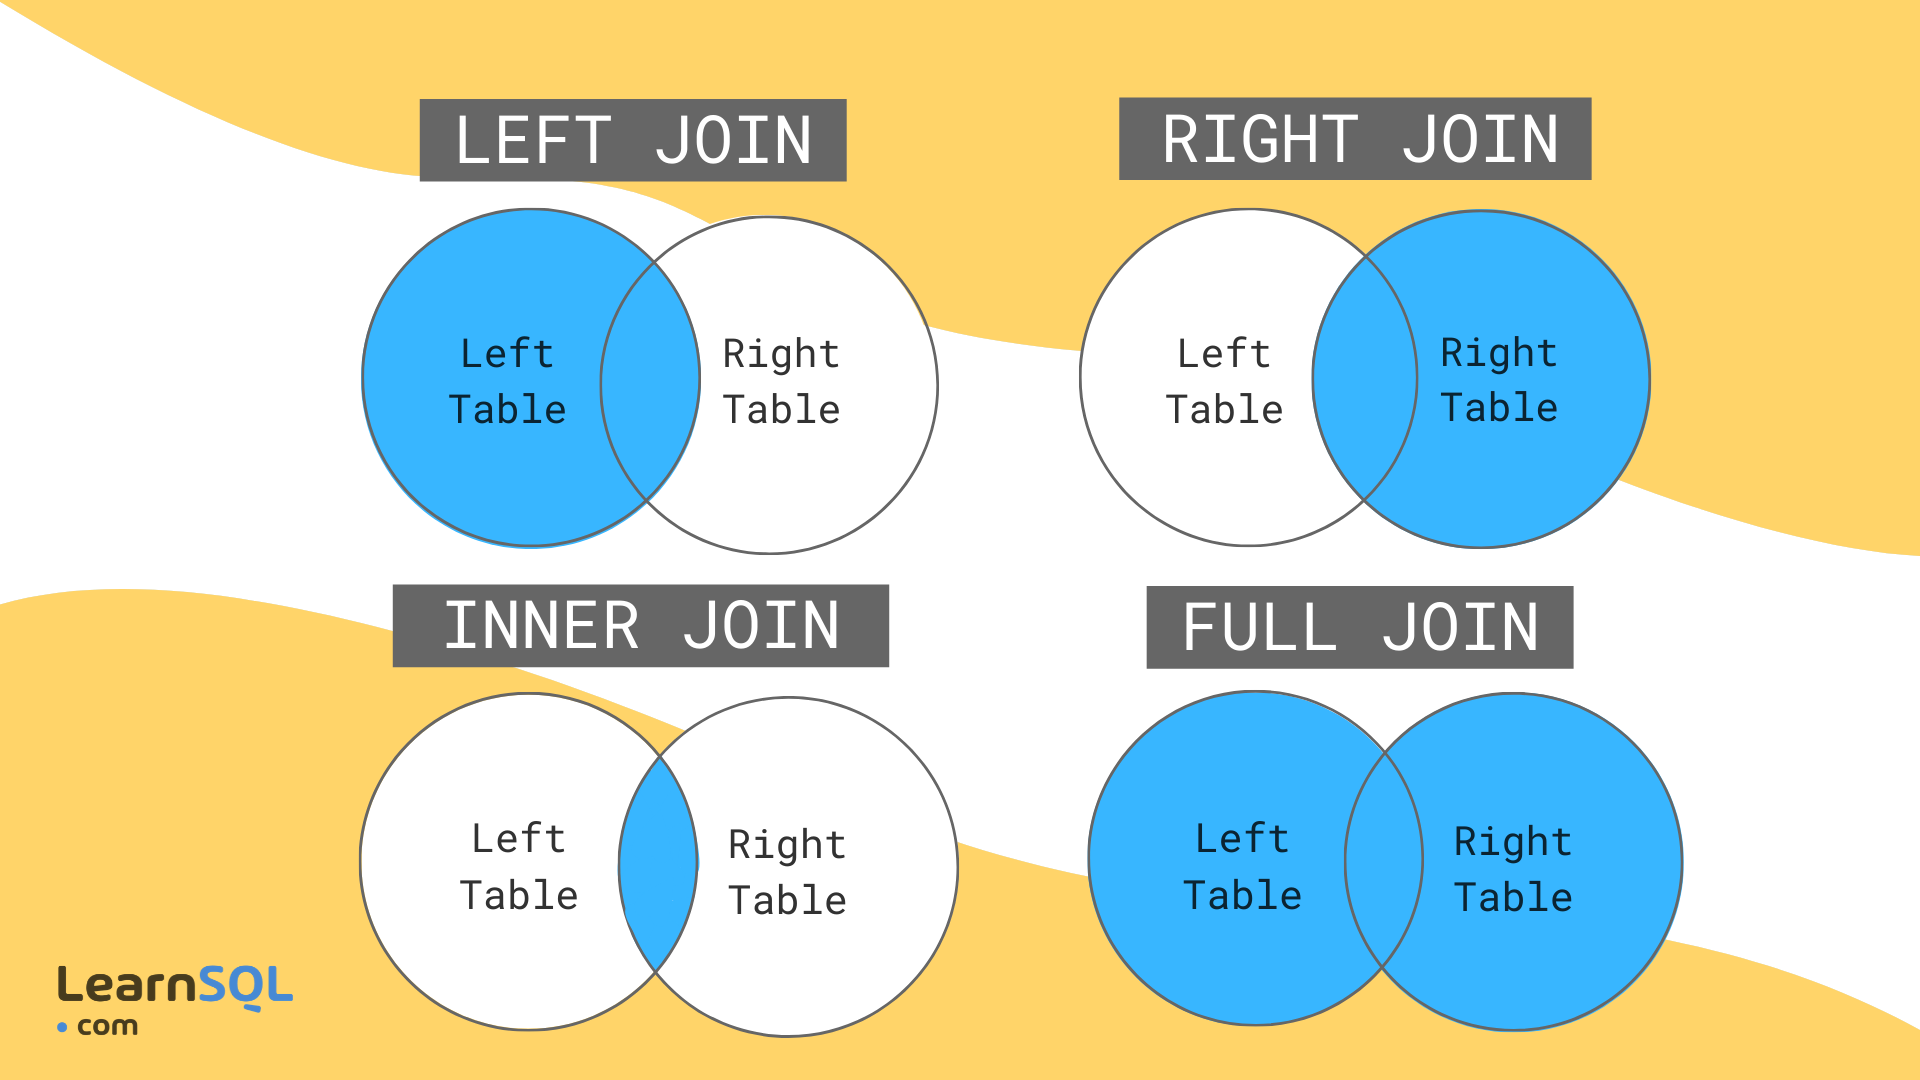

In [35]:
display(week1)
display(foods) #dimensional table

,Customer ID,Food ID
0,537,9
1,97,4
2,658,1
3,202,2
4,155,9
...,...,...
245,413,9
246,926,6
247,134,3
248,396,6


,Food ID,Food Item,Price
0,1,Sushi,3.99
1,2,Burrito,9.99
2,3,Taco,2.99
3,4,Quesadilla,4.25
4,5,Pizza,2.49
5,6,Pasta,13.99
6,7,Steak,24.99
7,8,Salad,11.25
8,9,Donut,0.99
9,10,Drink,1.75


In [36]:
display(week1.merge(foods, how="inner", on= "Food ID"))

,Customer ID,Food ID,Food Item,Price
0,537,9,Donut,0.99
1,97,4,Quesadilla,4.25
2,658,1,Sushi,3.99
3,202,2,Burrito,9.99
4,155,9,Donut,0.99
...,...,...,...,...
245,413,9,Donut,0.99
246,926,6,Pasta,13.99
247,134,3,Taco,2.99
248,396,6,Pasta,13.99


## Parámetros `left_on` y `right_on` 🎯
- Los parámetros `left_on` y `right_on` designan los nombres de las columnas en cada **DataFrame** que se usarán para realizar el merge.


In [ ]:
week2.head()

,Customer ID,Food ID
0,688,1
1,813,7
2,495,1
3,189,5
4,267,3


In [40]:
customers.head() #tablas diemnsionales -> responden preguntas

display(week2.merge(customers, how="left", right_on = "ID", left_on = "Customer ID"))
display(week2.merge(customers, how="left", left_on="Customer ID", right_on="ID").drop(["ID", "Occupation"], axis="columns"))

,Customer ID,Food ID,ID,First Name,Last Name,Gender,Company,Occupation
0,688,1,688,Carl,Williamson,Male,Thoughtmix,Graphic Designer
1,813,7,813,Johnny,Walker,Male,Kayveo,Developer II
2,495,1,495,Deborah,Little,Female,Babbleblab,VP Accounting
3,189,5,189,Roger,Gordon,Male,Skilith,Operator
4,267,3,267,Matthew,Wood,Male,Agimba,Product Engineer
...,...,...,...,...,...,...,...,...
245,783,1,783,Phyllis,Meyer,Female,Voolia,Information Systems Manager
246,556,1,556,Samuel,Bailey,Male,Oyoloo,Nurse
247,547,9,547,Tina,Watkins,Female,Thoughtstorm,Accountant II
248,252,9,252,Douglas,Powell,Male,Jetwire,Geologist IV


,Customer ID,Food ID,First Name,Last Name,Gender,Company
0,688,1,Carl,Williamson,Male,Thoughtmix
1,813,7,Johnny,Walker,Male,Kayveo
2,495,1,Deborah,Little,Female,Babbleblab
3,189,5,Roger,Gordon,Male,Skilith
4,267,3,Matthew,Wood,Male,Agimba
...,...,...,...,...,...,...
245,783,1,Phyllis,Meyer,Female,Voolia
246,556,1,Samuel,Bailey,Male,Oyoloo
247,547,9,Tina,Watkins,Female,Thoughtstorm
248,252,9,Douglas,Powell,Male,Jetwire


## Joins Internos (Inner Joins) I 🔄
- Los **inner joins** combinan dos tablas basándose en valores *compartidos*/*comunes* en columnas.
- Si un valor solo existe en uno de los **DataFrames**, se excluye del resultado final.
- Si un ID ocurre varias veces, pandas genera todas las combinaciones posibles de valores.
- Los resultados serán los mismos sin importar en qué **DataFrame** se invoque el método `merge`.

In [42]:
display(week1[week1["Customer ID"] == 155])
display(week2[week2["Customer ID"] == 155])

display(week1.merge(week2, how="inner", on="Customer ID", suffixes=[" - Week 1", " - Week 2"]))

,Customer ID,Food ID
4,155,9
17,155,1


,Customer ID,Food ID
208,155,3


,Customer ID,Food ID - Week 1,Food ID - Week 2
0,537,9,5
1,155,9,3
2,503,5,8
3,503,5,9
4,155,1,3
...,...,...,...
57,945,5,4
58,343,3,5
59,343,3,2
60,343,3,7


## Joins Internos (Inner Joins) II 🔄
- Es posible pasar múltiples argumentos al parámetro `on` del método `merge`.
- Pandas requerirá coincidencias en ambas columnas especificadas en los **DataFrames** para incluir los datos en el resultado final.



In [ ]:
week1.head()

,Customer ID,Food ID
0,537,9
1,97,4
2,658,1
3,202,2
4,155,9


In [ ]:
week2.head()

,Customer ID,Food ID
0,688,1
1,813,7
2,495,1
3,189,5
4,267,3


In [ ]:
week1.merge(week2, how="inner", on=["Customer ID", "Food ID"])

,Customer ID,Food ID
0,304,3
1,540,3
2,937,1
3,233,3
4,21,4
5,922,1
6,163,1
7,21,4
8,578,5
9,578,5


In [ ]:

#Ejemplo de filtro con mascara de 2 condiciones
condition_one = week1["Customer ID"] == 578
condition_two = week1["Food ID"] == 5
week1[condition_one & condition_two]

,Customer ID,Food ID
224,578,5


In [ ]:
condition_one = week2["Customer ID"] == 578
condition_two = week2["Food ID"] == 5
week2[condition_one & condition_two]

,Customer ID,Food ID
29,578,5
189,578,5


## Joins Completos/Externos (Full/Outer Joins) 🌍
- Un **full/outer join** combina valores encontrados en cualquiera de los **DataFrames** o en ambos.
- Pandas incluye valores incluso si solo existen en uno de los **DataFrames**.
- Si un valor no está presente en un **DataFrame**, se llenará con `NaN`.

In [ ]:
week1.head()

,Customer ID,Food ID
0,537,9
1,97,4
2,658,1
3,202,2
4,155,9


In [ ]:
week2.head()

,Customer ID,Food ID
0,688,1
1,813,7
2,495,1
3,189,5
4,267,3


In [ ]:
week1.merge(week2, how="outer", on="Customer ID", suffixes=[" - Week 1", " - Week 2"])
week1.merge(week2, how="outer", on="Customer ID", suffixes=[" - Week 1", " - Week 2"], indicator=True)

,Customer ID,Food ID - Week 1,Food ID - Week 2,_merge
0,3,2.0,NaN,left_only
1,8,NaN,6.0,right_only
2,10,2.0,NaN,left_only
3,13,NaN,2.0,right_only
4,20,1.0,NaN,left_only
...,...,...,...,...
449,985,5.0,NaN,left_only
450,991,2.0,NaN,left_only
451,994,NaN,2.0,right_only
452,996,NaN,1.0,right_only


In [ ]:
merged = week1.merge(week2, how="outer", on="Customer ID", suffixes=[" - Week 1", " - Week 2"], indicator=True)
merged["_merge"].value_counts()

merged[merged["_merge"].isin(["left_only", "right_only"])]

,Customer ID,Food ID - Week 1,Food ID - Week 2,_merge
0,3,2.0,NaN,left_only
1,8,NaN,6.0,right_only
2,10,2.0,NaN,left_only
3,13,NaN,2.0,right_only
4,20,1.0,NaN,left_only
...,...,...,...,...
449,985,5.0,NaN,left_only
450,991,2.0,NaN,left_only
451,994,NaN,2.0,right_only
452,996,NaN,1.0,right_only


## Combinar por Índices con los Parámetros `left_index` y `right_index` 🔗
- Usa el parámetro `on` si las columnas que se deben combinar tienen el mismo nombre en ambos **DataFrames**.
- Usa los parámetros `left_on` y `right_on` si las columnas a combinar tienen nombres diferentes en los dos **DataFrames**.
- Usa los parámetros `left_index` o `right_index` (establecidos en `True`) si los valores a combinar se encuentran en el índice de un **DataFrame**.


In [ ]:
foods = pd.read_csv("restaurant_foods.csv", index_col="Food ID", sep = ";")
customers = pd.read_csv("restaurant_customers.csv", index_col="ID", sep =";")
week1 = pd.read_csv("restaurant_week_1_sales.csv",sep =";")
week2 = pd.read_csv("restaurant_week_2_sales.csv",sep =";")

In [ ]:
week1.head()

,Customer ID,Food ID
0,537,9
1,97,4
2,658,1
3,202,2
4,155,9


In [ ]:
customers.head()

,First Name,Last Name,Gender,Company,Occupation
ID,,,,,
1,Joseph,Perkins,Male,Dynazzy,Community Outreach Specialist
2,Jennifer,Alvarez,Female,DabZ,Senior Quality Engineer
3,Roger,Black,Male,Tagfeed,Account Executive
4,Steven,Evans,Male,Fatz,Registered Nurse
5,Judy,Morrison,Female,Demivee,Legal Assistant


In [ ]:
foods.head()

,Food Item,Price
Food ID,,
1,Sushi,3.99
2,Burrito,9.99
3,Taco,2.99
4,Quesadilla,4.25
5,Pizza,2.49


In [ ]:
week1.merge(customers, how="left", left_on="Customer ID", right_index=True).merge(foods, how="left", left_on="Food ID", right_index=True)

,Customer ID,Food ID,First Name,Last Name,Gender,Company,Occupation,Food Item,Price
0,537,9,Cheryl,Carroll,Female,Zoombeat,Registered Nurse,Donut,0.99
1,97,4,Amanda,Watkins,Female,Ozu,Account Coordinator,Quesadilla,4.25
2,658,1,Patrick,Webb,Male,Browsebug,Community Outreach Specialist,Sushi,3.99
3,202,2,Louis,Campbell,Male,Rhynoodle,Account Representative III,Burrito,9.99
4,155,9,Carolyn,Diaz,Female,Gigazoom,Database Administrator III,Donut,0.99
...,...,...,...,...,...,...,...,...,...
245,413,9,Diane,Bailey,Female,Wikibox,Technical Writer,Donut,0.99
246,926,6,Anne,Wagner,Female,Skyba,Legal Assistant,Pasta,13.99
247,134,3,Diana,Hall,Female,Quinu,Financial Advisor,Taco,2.99
248,396,6,Juan,Romero,Male,Zoonder,Analyst Programmer,Pasta,13.99


## El Método `join` ⚡
- El método `join` es un atajo para concatenar dos **DataFrames** cuando se combinan utilizando las etiquetas de índice.


In [ ]:
foods = pd.read_csv("restaurant_foods.csv")
customers = pd.read_csv("restaurant_customers.csv", sep=";")
week1 = pd.read_csv("restaurant_week_1_sales.csv", sep=";")
week2 = pd.read_csv("restaurant_week_2_sales.csv", sep=";")
times = pd.read_csv("restaurant_week_1_times.csv", sep=";")

In [ ]:
week1.head()

,Customer ID,Food ID
0,537,9
1,97,4
2,658,1
3,202,2
4,155,9


In [ ]:
times.head()

,Time of Day
0,14:54:59
1,20:55:17
2,01:16:22
3,16:17:26
4,19:26:11


In [ ]:
week1.merge(times, how="left", left_index=True, right_index=True) # = week1.join(times)

,Customer ID,Food ID,Time of Day
0,537,9,14:54:59
1,97,4,20:55:17
2,658,1,01:16:22
3,202,2,16:17:26
4,155,9,19:26:11
...,...,...,...
245,413,9,04:44:14
246,926,6,07:46:21
247,134,3,20:45:08
248,396,6,01:09:06


In [ ]:
week1.join(times) # = week1.merge(times, how="left", left_index=True, right_index=True)

,Customer ID,Food ID,Time of Day
0,537,9,14:54:59
1,97,4,20:55:17
2,658,1,01:16:22
3,202,2,16:17:26
4,155,9,19:26:11
...,...,...,...
245,413,9,04:44:14
246,926,6,07:46:21
247,134,3,20:45:08
248,396,6,01:09:06
